In [1]:
import polars as pl
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import os
from collections import defaultdict
import datetime as dt
from pathlib import Path
import sys
sys.path.insert(1, os.path.abspath(".."))
os.chdir(os.path.abspath('..')) # Change the workdir to the parent folder

In [2]:
from src.configs.dataconfig import input_output_config
from src.utils.utils import load_df

In [3]:
df_all = load_df(input_output_config.output_path, "df_all.parquet")
df_sirs = load_df(input_output_config.output_path, "df_sirs.parquet")
df_agg = load_df(input_output_config.output_path, "df_agg.parquet")
df_sepsis1 = load_df(input_output_config.output_path, "df_sepsis1.parquet")
df_sepsis2 = load_df(input_output_config.output_path, "df_sepsis2.parquet")
df_sepsis3 = load_df(input_output_config.output_path, "df_sepsis3.parquet")
df_septicshock = load_df(input_output_config.output_path, "df_septicshock.parquet")
df_infect = load_df(input_output_config.output_path, "df_infect_long.parquet")

### Notes:
1. Cancer and transplant are very difficult to assess physiologically 
2. Heart disease (Cardiogenic) and septic shock are the hardest because you can not give them fluids or you will kill them
3. I need to differentiate between sirs (sepsis components in general) with and without infection. SIRS can jump to 1 and go back to zero, or jumpy from 1 to 2.

### Questions:
1. How many blood cultures do a patient get?
2. Is there a way to know if the antibiotic stopped?
3. How does the distribution of SIRS level duration change if it is around an infection?

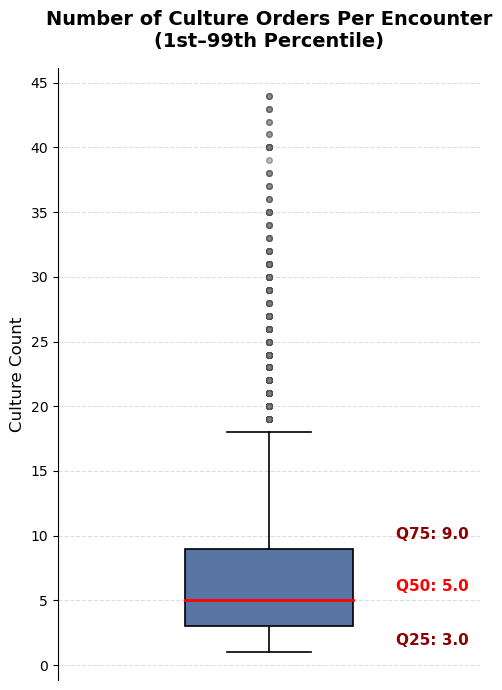

In [4]:
# cnt = (
#     df_all.filter(pl.col("Event_Grouper").str.to_lowercase().str.contains("culture"))
# 	.group_by("EncounterEpicCsn").agg(
#         pl.len().alias("count")
# 	)
#     .filter(
#         (pl.col("count") <= pl.col("count").quantile(0.99))&
#         (pl.col("count") >= pl.col("count").quantile(0.01))
# 	)
    
# )['count']

# ax = sns.boxplot(cnt.to_numpy())
# # ax.axhline(y=cnt.quantile(0.5), color='red', linestyle='dashed', linewidth=2)
# ax.text(-0.4, cnt.quantile(0.75)+0.3, f"Q50: {cnt.quantile(0.75):.2f}", fontsize=12, color='red')
# ax.text(0.0, cnt.quantile(0.5)+0.3, f"Q50: {cnt.quantile(0.5):.2f}", fontsize=12, color='red')
# ax.text(0.4, cnt.quantile(0.25)-0.3, f"Q50: {cnt.quantile(0.25):.2f}", fontsize=12, color='red')

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Data ──
cnt = (
    df_all.filter(pl.col("Event_Grouper").str.to_lowercase().str.contains("culture"))
    .group_by("EncounterEpicCsn").agg(
        pl.len().alias("count")
    )
    .filter(
        (pl.col("count") <= pl.col("count").quantile(0.99)) &
        (pl.col("count") >= pl.col("count").quantile(0.01))
    )
)["count"]

q25 = cnt.quantile(0.25)
q50 = cnt.quantile(0.5)
q75 = cnt.quantile(0.75)

# ── Plot ──
fig, ax = plt.subplots(figsize=(5, 7))

sns.boxplot(
    y=cnt.to_numpy(),
    ax=ax,
    width=0.4,
    color="#4C72B0",
    flierprops=dict(marker="o", markerfacecolor="grey", markersize=4, alpha=0.5),
    medianprops=dict(color="red", linewidth=2),
    boxprops=dict(edgecolor="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
)

# ── Quartile Annotations ──
offset = (q75 - q25) * 0.08  # dynamic offset based on IQR

ax.text(0.30, q75 + offset, f"Q75: {q75:.1f}", fontsize=11, color="darkred", fontweight="bold", va="bottom")
ax.text(0.30, q50 + offset, f"Q50: {q50:.1f}", fontsize=11, color="red", fontweight="bold", va="bottom")
ax.text(0.30, q25 - offset, f"Q25: {q25:.1f}", fontsize=11, color="darkred", fontweight="bold", va="top")

# ── Labels & Styling ──
ax.set_title("Number of Culture Orders Per Encounter\n(1st–99th Percentile)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Culture Count", fontsize=12)
ax.set_xticks([])                          # remove meaningless x-tick
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))  # integer ticks
ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine(left=False, bottom=True)       # clean up spines

fig.tight_layout()
plt.show()


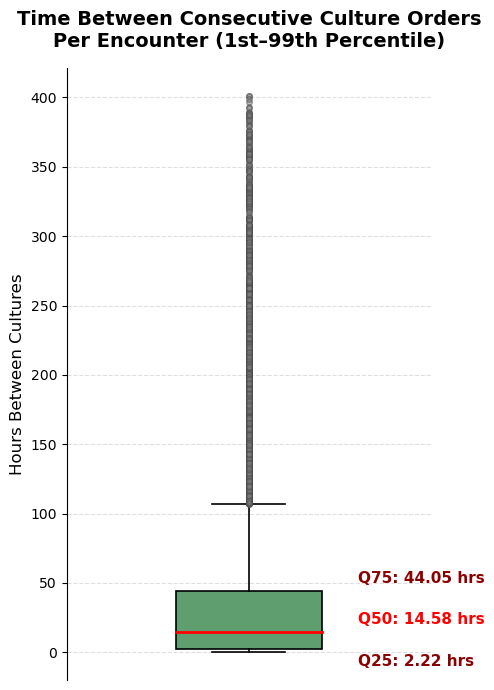

In [5]:
# df_cultures = (
#     df_all.filter(pl.col("Event_Grouper").str.to_lowercase().str.contains("culture"))
# 	.select(["EncounterEpicCsn", "Event_DateTime", "Type", "Event_Grouper", "Event_Name", "Value"])
# 	.filter(pl.col("Type")=="Procedure Order")
# 	.sort(by=['EncounterEpicCsn', 'Event_DateTime'])	
# 	.with_columns(
#         pl.col("Event_DateTime").shift(1).over("EncounterEpicCsn").alias("prev_Event_DateTime")
# 	).with_columns(
# 		time_diff = (pl.col("Event_DateTime")-pl.col("prev_Event_DateTime")).dt.total_hours(fractional=True)
# 	)
#     .unique(subset=['EncounterEpicCsn', 'Event_DateTime'])
# )

# cnt = df_cultures.filter(
#         (pl.col("time_diff") <= pl.col("time_diff").quantile(0.99))&
# 		(pl.col("time_diff") >= pl.col("time_diff").quantile(0.01))
# 	)['time_diff']
	

# ax = sns.boxplot(
# 	data=df_cultures.filter(
#         (pl.col("time_diff") <= pl.col("time_diff").quantile(0.99))&
# 		(pl.col("time_diff") >= pl.col("time_diff").quantile(0.01))
# 	).to_pandas(),
# 	y='time_diff'
# )
# ax.text(-0.4, cnt.quantile(0.75)+0.3, f"Q75: {cnt.quantile(0.75):.2f}", fontsize=12, color='red')
# ax.text(0.0, cnt.quantile(0.5)+0.3, f"Q50: {cnt.quantile(0.5):.2f}", fontsize=12, color='red')
# ax.text(0.4, cnt.quantile(0.25)-0.3, f"Q25: {cnt.quantile(0.25):.2f}", fontsize=12, color='red')	
# ── Data ──
df_cultures = (
    df_all.filter(pl.col("Event_Grouper").str.to_lowercase().str.contains("culture"))
    .select(["EncounterEpicCsn", "Event_DateTime", "Type", "Event_Grouper", "Event_Name", "Value"])
    .filter(pl.col("Type") == "Procedure Order")
    .unique(subset=["EncounterEpicCsn", "Event_DateTime"])
    .sort(["EncounterEpicCsn", "Event_DateTime"])
    .with_columns(
        pl.col("Event_DateTime").shift(1).over("EncounterEpicCsn").alias("prev_Event_DateTime")
    )
    .with_columns(
        time_diff=(pl.col("Event_DateTime") - pl.col("prev_Event_DateTime")).dt.total_hours(fractional=True)
    )
    .filter(pl.col("time_diff").is_not_null())  # explicitly drop first-per-encounter
)

cnt = df_cultures.filter(
    (pl.col("time_diff") <= pl.col("time_diff").quantile(0.99)) &
    (pl.col("time_diff") >= pl.col("time_diff").quantile(0.01))
)["time_diff"]

q25 = cnt.quantile(0.25)
q50 = cnt.quantile(0.5)
q75 = cnt.quantile(0.75)

# ── Plot ──
fig, ax = plt.subplots(figsize=(5, 7))

sns.boxplot(
    y=cnt.to_numpy(),
    ax=ax,
    width=0.4,
    color="#55A868",
    flierprops=dict(marker="o", markerfacecolor="grey", markersize=4, alpha=0.5),
    medianprops=dict(color="red", linewidth=2),
    boxprops=dict(edgecolor="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
)

# ── Quartile Annotations ──
offset = (q75 - q25) * 0.08

ax.text(0.30, q75 + offset, f"Q75: {q75:.2f} hrs", fontsize=11, color="darkred", fontweight="bold", va="bottom")
ax.text(0.30, q50 + offset, f"Q50: {q50:.2f} hrs", fontsize=11, color="red", fontweight="bold", va="bottom")
ax.text(0.30, q25 - offset, f"Q25: {q25:.2f} hrs", fontsize=11, color="darkred", fontweight="bold", va="top")

# ── Labels & Styling ──
ax.set_title("Time Between Consecutive Culture Orders\nPer Encounter (1st–99th Percentile)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Hours Between Cultures", fontsize=12)
ax.set_xticks([])
ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine(left=False, bottom=True)

fig.tight_layout()
plt.show()


In [14]:
df_agg.select(
    ["EncounterEpicCsn", "Event_DateTime", "last_lactate_6h"]
).with_columns(
    pl.when(pl.col("last_lactate_6h") > 2).then(pl.lit(1)).otherwise(pl.lit(0)).alias('lactate_6h_flag')
).sort(by=['EncounterEpicCsn', 'Event_DateTime'])

EncounterEpicCsn,Event_DateTime,last_lactate_6h,lactate_6h_flag
i64,datetime[μs],f64,i32
699476058,2024-03-06 03:09:37.020,null,0
699476058,2024-04-30 03:39:43.660,null,0
699476058,2024-04-30 06:15:00,null,0
699476058,2024-04-30 06:25:00,null,0
699476058,2024-04-30 07:05:00,null,0
…,…,…,…
747311714,2026-02-28 02:15:39.777,null,0
747311714,2026-03-01 02:54:35.660,null,0
747311714,2026-03-03 02:39:48.620,null,0


In [ ]:
df_agg.group_by("EncounterEpicCsn").agg(
    pl.col("last_lactate_6h").is_not_null().any().cast(pl.Int32)
)['last_lactate_6h'].value_counts()

last_lactate_6h,count
i32,u64
1,3573
0,410


In [7]:
df_lact = (
	df_all.select(["EncounterEpicCsn", "Event_DateTime"]).unique().join(
		df_all
		.select(
			["EncounterEpicCsn", "Event_DateTime", "Event_Grouper", "Type", "NumericValue"]
		)
		.filter(
			(pl.col("Event_Grouper") == 'Lactate')&
			(pl.col("Type") == 'Lab Results')
		),
		on=['EncounterEpicCsn'],
		suffix='_lact',
		how='left'
	)
    .filter(
		(pl.col("Event_DateTime") <= pl.col("Event_DateTime_lact") + pl.duration(hours=6) )&
		(pl.col("Event_DateTime") >=  pl.col("Event_DateTime_lact"))
	)
    .sort(by=["EncounterEpicCsn", "Event_DateTime", "Event_DateTime_lact"])
	.with_columns(
        lactate_flag = pl.col("NumericValue") > 2
	)
)

In [8]:
df_lact

EncounterEpicCsn,Event_DateTime,Event_DateTime_lact,Event_Grouper,Type,NumericValue,lactate_flag
i64,datetime[μs],datetime[μs],str,str,f64,bool
699476058,2024-04-30 09:14:00,2024-04-30 09:14:00,"""Lactate""","""Lab Results""",1.5,false
699476058,2024-04-30 10:26:00,2024-04-30 09:14:00,"""Lactate""","""Lab Results""",1.5,false
699476058,2024-04-30 10:26:00,2024-04-30 10:26:00,"""Lactate""","""Lab Results""",2.2,true
699476058,2024-04-30 11:24:00,2024-04-30 09:14:00,"""Lactate""","""Lab Results""",1.5,false
699476058,2024-04-30 11:24:00,2024-04-30 10:26:00,"""Lactate""","""Lab Results""",2.2,true
…,…,…,…,…,…,…
747311714,2026-02-27 11:00:00,2026-02-27 08:05:00,"""Lactate""","""Lab Results""",7.6,true
747311714,2026-02-27 11:14:00,2026-02-27 08:05:00,"""Lactate""","""Lab Results""",7.6,true
747311714,2026-02-27 11:15:00,2026-02-27 08:05:00,"""Lactate""","""Lab Results""",7.6,true


In [ ]:
(
    df_all
	.select(
		["EncounterEpicCsn", "Event_DateTime", "Event_Grouper", "Type", "NumericValue"]
	)
	.filter(
		(pl.col("Event_Grouper") == 'Lactate')&
		(pl.col("Type") == 'Lab Results')
	)
    .sort(by=["EncounterEpicCsn", "Event_DateTime"])
	.with_columns(
        pl.col("Event_DateTime").shift(1).over("EncounterEpicCsn").alias("prev_Event_DateTime")
	).with_columns(
		time_diff = (pl.col("Event_DateTime")-pl.col("prev_Event_DateTime")).dt.total_hours(fractional=True)
	)

)

EncounterEpicCsn,Event_DateTime,Event_Grouper,Type,NumericValue,prev_Event_DateTime,time_diff
i64,datetime[μs],str,str,f64,datetime[μs],f64
699476058,2024-04-30 09:14:00,"""Lactate""","""Lab Results""",1.5,null,null
699476058,2024-04-30 10:26:00,"""Lactate""","""Lab Results""",2.2,2024-04-30 09:14:00,1.2
699476058,2024-04-30 11:24:00,"""Lactate""","""Lab Results""",2.9,2024-04-30 10:26:00,0.966667
699476058,2024-04-30 14:10:00,"""Lactate""","""Lab Results""",7.4,2024-04-30 11:24:00,2.766667
699476058,2024-04-30 15:09:00,"""Lactate""","""Lab Results""",7.2,2024-04-30 14:10:00,0.983333
…,…,…,…,…,…,…
747311714,2026-02-26 18:00:00,"""Lactate""","""Lab Results""",8.5,2026-02-26 15:53:00,2.116667
747311714,2026-02-26 20:46:00,"""Lactate""","""Lab Results""",6.8,2026-02-26 18:00:00,2.766667
747311714,2026-02-27 00:18:00,"""Lactate""","""Lab Results""",5.9,2026-02-26 20:46:00,3.533333


In [11]:
df_lactate_6994 = df_agg.select(["EncounterEpicCsn", "Event_DateTime", 'last_lactate_6h']).filter(
    pl.col("last_lactate_6h").is_not_null()
    # (pl.col("EncounterEpicCsn") == 699476058)
).sort(by=['EncounterEpicCsn', 'Event_DateTime'])


fig = px.scatter(
    data_frame=df_lactate_6994.filter(pl.col("Event_DateTime") <= dt.datetime(2024, 5, 2)).to_pandas(),
    x="Event_DateTime",
    y="last_lactate_6h",
    title="Lactate Levels Over Time — Encounter 699476058",
    labels={
        "Event_DateTime": "Event Date & Time",
        "last_lactate_6h": "Last Lactate (6h Window, mmol/L)",
    },
    opacity=0.75,
)

# --- Layout & Styling ---
fig.update_traces(
    marker=dict(
        size=9,
        color="#1F77B4",            # clean blue
        line=dict(width=1, color="white"),  # white border for contrast
    ),
    name="Lactate Value",           # legend label
    showlegend=True,
)

fig.update_layout(
    title=dict(
        font=dict(size=20, family="Arial"),
        x=0.5,                      # center the title
        xanchor="center",
    ),
    xaxis=dict(
        title_font=dict(size=14),
        tickfont=dict(size=11),
        showgrid=True,
        gridcolor="rgba(200,200,200,0.3)",
    ),
    yaxis=dict(
        title_font=dict(size=14),
        tickfont=dict(size=11),
        showgrid=True,
        gridcolor="rgba(200,200,200,0.3)",
    ),
    legend=dict(
        title="Legend",
        font=dict(size=12),
        bordercolor="lightgray",
        borderwidth=1,
    ),
    plot_bgcolor="white",           # clean white background
    margin=dict(l=60, r=30, t=80, b=60),
    width=2500,
    height=750,
)

fig.show()

In [39]:
# sorted(df_all['Event_Grouper'].unique().to_list())

In [12]:
df_lactate_6994_raw = df_all.filter(
    (pl.col("Event_Grouper") == 'Lactate')&
	(pl.col("Type") == "Lab Results")
    # (pl.col("EncounterEpicCsn") == 699476058)
).sort(by=['EncounterEpicCsn', 'Event_DateTime']).with_columns(
    pl.col("Event_DateTime").shift(1).over("EncounterEpicCsn").alias("prev_Event_DateTime"),
).with_columns(
    (pl.col("Event_DateTime")-pl.col("prev_Event_DateTime")).dt.total_hours(fractional=True).alias("time_diff")
).select(
    ["EncounterEpicCsn", "Event_DateTime", "Type", "Event_Grouper", "time_diff"]
)

px.histogram(
    data_frame=df_lactate_6994_raw.filter(
        pl.col("Event_DateTime") <= dt.datetime(2024, 5, 15)
	),
    x="time_diff",
    nbins=50
)

In [ ]:
(
    df_sepsis2
    .select(
		["EncounterEpicCsn", "infect_dt", "Event_DateTime"]+
		['last_lactate_6h', 'cardiovascular_failure_flag', 'organ_dysfunction']+
        ['earliest_sepsis2_instance']
    )
	.filter(
    pl.col('last_lactate_6h') >=2 
)

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type,Event_DateTime,last_temp_8h,last_pulse_8h,last_resp_8h,last_sbp_8h,last_map_8h,last_wbc_12h,last_creatinine_12h,last_egfr_12h,last_bilirubin_12h,last_lactate_6h,last_platelets_24h,last_inr_12h,last_aptt_24h,last_gcs_12h,last_vasopressin_24h,last_phenylephrine_24h,last_norepinephrine_24h,last_epinephrine_24h,vent_status_time,vent_status_flag,Baseline_Creatinine,Baseline_eGFR,Baseline_Bilirubin,Baseline_Platelets,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_WBC,cardiovascular_failure_flag,coagulation_failure_flag,platelets50_criteria_flag,aptt_criteria_flag,platelets100_criteria_flag,inr_criteria_flag,pulmonary_failure_flag,renal_failure_flag,hepatic_failure_flag,neurological_failure_flag,organ_dysfunction_total,earliest_sepsis2_instance
i64,str,datetime[μs],str,datetime[μs],f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i64,i32,i32,i64,i64,datetime[μs]
699476058,"""iv_dt""",2024-05-01 01:31:25,"""IV+Culture""",2024-04-30 11:24:00,97.5,94.0,16.0,103,null,null,null,null,null,2.2,null,null,null,15.0,null,null,null,null,null,null,1.413333,49.0,0.7,298.5,120.0,15.0,97.0,8.765,1,0,0,0,0,0,0,0,0,0,1,2024-04-30 11:24:00
717740076,"""culture_dt""",2024-12-15 17:52:00,"""LACTATE+CULTURE""",2024-12-16 00:04:00,97.6,88.0,20.0,115,null,null,null,null,null,2.1,null,null,null,15.0,null,null,null,null,null,"""Vent off Documentation""",0.607333,100.36,0.576364,209.190476,109.0,16.0,85.0,9.43955,1,0,0,0,0,0,0,0,0,0,1,2024-12-15 17:52:00
718440619,"""culture_dt""",2024-12-27 14:09:00,"""IV+Culture""",2024-12-27 15:00:00,98.8,71.0,18.0,90,null,null,null,null,null,2.3,null,null,null,15.0,null,null,null,null,null,null,2.967105,36.652174,5.497826,45.888889,107.0,null,76.0,11.257647,1,0,0,0,0,0,0,0,0,0,1,2024-12-27 14:09:00
718783901,"""iv_dt""",2025-03-12 20:40:00,"""IV+Culture""",2025-03-11 12:49:00,97.6,110.0,16.0,151,null,null,null,null,null,3.0,null,null,null,15.0,null,null,null,null,null,null,1.36,58.0,1.7,225.5,122.0,17.0,115.0,5.7725,1,0,0,0,0,0,0,0,0,0,1,2025-03-11 12:49:00
719032098,"""iv_dt""",2025-01-22 01:06:27,"""IV+Culture""",2025-01-22 00:05:00,97.7,118.0,30.0,118,null,15.28,null,null,null,2.2,454.0,null,null,15.0,null,null,null,null,null,null,1.202667,72.828889,0.8,411.705882,99.0,null,null,11.836364,1,0,0,0,0,0,0,0,0,0,1,2025-01-22 00:05:00
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
747065278,"""culture_dt""",2026-02-23 10:35:00,"""IV+Culture""",2026-02-23 11:00:00,98.0,76.0,17.0,100,null,null,null,null,null,3.6,null,null,null,15.0,null,null,null,null,null,null,1.611667,52.333333,0.55,265.666667,134.0,16.0,67.0,6.841111,1,0,0,0,0,0,0,0,0,0,1,2026-02-23 10:35:00
747125007,"""culture_dt""",2026-02-23 16:58:00,"""LACTATE+CULTURE""",2026-02-23 18:15:00,98.3,115.0,17.0,93,null,7.49,1.89,51.0,0.27,2.0,85.0,null,null,null,null,null,null,null,null,"""Vent off Documentation""",1.0,114.901869,0.478624,153.979798,null,null,null,13.058713,0,0,0,0,0,0,0,1,0,0,1,2026-02-23 16:58:00
747181645,"""culture_dt""",2026-02-24 14:37:00,"""LACTATE+CULTURE""",2026-02-24 15:52:00,102.9,82.0,16.0,117,null,null,null,null,null,2.2,null,null,null,15.0,null,null,null,null,null,null,null,null,null,null,136.0,16.0,62.0,null,1,0,0,0,0,0,0,0,0,0,1,2026-02-24 14:37:00


In [ ]:
df_sepsis1

In [4]:
df_sepsis2

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type,Event_DateTime,last_temp_8h,last_pulse_8h,last_resp_8h,last_sbp_8h,last_map_8h,last_wbc_12h,last_creatinine_12h,last_egfr_12h,last_bilirubin_12h,last_lactate_6h,last_platelets_24h,last_inr_12h,last_aptt_24h,last_gcs_12h,last_vasopressin_24h,last_phenylephrine_24h,last_norepinephrine_24h,last_epinephrine_24h,vent_status_time,vent_status_flag,Baseline_Creatinine,Baseline_eGFR,Baseline_Bilirubin,Baseline_Platelets,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_WBC,cardiovascular_failure_flag,coagulation_failure_flag,platelets50_criteria_flag,aptt_criteria_flag,platelets100_criteria_flag,inr_criteria_flag,pulmonary_failure_flag,renal_failure_flag,hepatic_failure_flag,neurological_failure_flag,organ_dysfunction_total,earliest_sepsis2_instance
i64,str,datetime[μs],str,datetime[μs],f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i64,i32,i32,i64,i64,datetime[μs]
699476058,"""iv_dt""",2024-05-01 01:31:25,"""IV+Culture""",2024-04-30 11:24:00,97.5,94.0,16.0,103,null,null,null,null,null,2.2,null,null,null,15.0,null,null,null,null,null,null,1.413333,49.0,0.7,298.5,120.0,15.0,97.0,8.765,1,0,0,0,0,0,0,0,0,0,1,2024-04-30 11:24:00
709516764,"""iv_dt""",2025-01-29 12:44:00,"""IV+Culture""",2025-01-28 14:45:00,96.8,93.0,15.0,141,null,null,null,null,null,null,null,null,null,14.0,null,null,null,null,null,null,0.8125,74.5,0.266667,238.0,133.0,18.0,93.0,10.2275,0,0,0,0,0,0,0,0,0,1,1,2025-01-28 14:45:00
714445951,"""iv_dt""",2024-10-26 17:19:00,"""IV+Culture""",2024-10-24 17:35:00,98.2,119.0,20.0,106,null,7.39,0.92,89.0,null,null,112.0,null,null,15.0,null,null,null,null,2024-10-24 16:28:00,"""O2 Delivery High-Flow""",0.868077,98.538462,0.857143,107.483871,101.0,19.0,110.0,5.735161,0,0,0,0,0,0,1,0,0,0,1,2024-10-24 17:35:00
714534044,"""iv_dt""",2024-10-26 09:44:38,"""IV+Culture""",2024-10-26 07:01:00,99.1,92.0,19.0,105,null,null,0.99,81.0,null,null,154.0,null,null,14.0,null,null,null,null,null,null,0.8,94.333333,1.266667,186.666667,128.0,null,92.0,6.09,0,0,0,0,0,0,0,0,0,1,1,2024-10-26 07:01:00
716208986,"""iv_dt""",2025-01-02 10:18:25,"""IV+Culture""",2024-12-31 15:00:00,97.8,83.0,18.0,115,null,4.03,3.18,21.0,null,null,185.0,null,null,14.0,null,null,null,null,null,null,3.409714,19.514286,0.27,120.34375,141.0,17.0,70.0,6.125,0,0,0,0,0,0,0,0,0,1,1,2024-12-31 15:00:00
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
747125007,"""culture_dt""",2026-02-23 16:58:00,"""LACTATE+CULTURE""",2026-02-23 18:15:00,98.3,115.0,17.0,93,null,7.49,1.89,51.0,0.27,2.0,85.0,null,null,null,null,null,null,null,null,"""Vent off Documentation""",1.0,114.901869,0.478624,153.979798,null,null,null,13.058713,0,0,0,0,0,0,0,1,0,0,1,2026-02-23 16:58:00
747181645,"""culture_dt""",2026-02-24 14:37:00,"""LACTATE+CULTURE""",2026-02-24 15:52:00,102.9,82.0,16.0,117,null,null,null,null,null,2.2,null,null,null,15.0,null,null,null,null,null,null,null,null,null,null,136.0,16.0,62.0,null,1,0,0,0,0,0,0,0,0,0,1,2026-02-24 14:37:00
747187332,"""culture_dt""",2026-02-24 12:24:00,"""IV+Culture""",2026-02-24 12:41:00,102.6,101.0,25.0,134,null,null,null,null,null,2.5,null,null,null,15.0,null,null,null,null,null,null,0.9125,87.789474,0.387778,178.05,117.0,16.0,88.0,7.7945,1,0,0,0,0,0,0,0,0,0,1,2026-02-24 12:24:00


In [20]:
df_sirs_sub = df_sirs.select(
    ["EncounterEpicCsn",
    "Event_DateTime",
	"Type",
    "Event_Grouper",
	"Event_Name",
	"Value"
	]+
	[
        "WBC_Abnormal_Flag",
        "Temp_Abnormal_Flag",
		"Resp_Rate_High_Flag",
        "Pule_High_Flag"
	]+
	["sirs_score"]
)

In [24]:
l = df_all['Event_Name'].unique().to_list()

# Check culture events
list(filter(lambda x: 'culture' in x.lower(), l))

# Check antibiotic events
list(filter(lambda x: 'antibiotic' in x.lower(), l))

# check adminstrated events
list(filter(lambda x: 'admin' in x.lower(), l))

['Anaphylactic reaction due to adverse effect of correct drug or medicament properly administered, initial encounter',
 'Steroid-induced diabetes mellitus (correct and properly administered) (*)',
 'Medication administered',
 'Status post administration of tPA (rtPA) in a different facility within the last 24 hours prior to admission to current facility',
 'Anaphylactic reaction due to administration of blood and blood products, initial encounter',
 'Contaminated medical or biological substance administered by unspecified means',
 'History of administration of pre-exposure prophylaxis for HIV']

In [25]:
df_all.filter(
    pl.col("Event_Name") == 'Medication administered'
)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
741965719,2025-12-19 02:30:41.207,"""Diagnosis Event""","""Encounter Diagnosis""","""Medication administered""",null,"""Z92.29""",null,99268987,741965719,2025-12-05 00:00:00,2025-12-27 00:00:00,2025-12-05 16:57:00,2025-12-05 22:21:00,"""Yes""","""Inpatient""","""Inpatient""","""MICU""","""22""","""UH OVERFLOW 03""","""UH 12O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Acute on chronic hypoxic respi…","""Sepsis, unspecified organism""","""Assistance with Resp Ventilati…",0,"""POA-2""","""POA-2""",88.0,null,null,0.71,null,0.8,101.0,null,"""2025-12-05 17:35:00.0000000""","""Suspected Infection Flowsheet""","""0""","""0""","""0""","""0""","""0""","""0"""
738317715,2025-10-21 02:16:06.650,"""Diagnosis Event""","""Encounter Diagnosis""","""Medication administered""",null,"""Z92.29""",null,96756489,738317715,2025-10-14 00:00:00,2025-10-29 00:00:00,2025-10-14 18:07:00,2025-10-14 18:07:00,"""No""","""Inpatient""","""Inpatient""","""Lung Transplant""","""15""","""UH 07B ICU""","""UH 10B HRT LNG""","""Emergency""","""Trans from Short Term General …","""Transfer Center Admission""","""Severe sepsis with septic shoc…","""Other specified complication o…","""Drainage of Right Lower Lung L…",0,"""POA-3""","""POA-3""",127.0,17.0,76.0,1.454,131.304348,0.511364,59.972222,3.561458,"""2025-10-14 18:06:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""1""","""0""","""1""","""0"""


In [17]:
len(df_antibiotic['Event_Name'].unique().to_list())

241

In [14]:
df_antibiotic = df_sirs_sub.filter(
    pl.col("Event_Grouper").is_in(['Antibiotics']) 
)
df_antibiotic.sort(by=['EncounterEpicCsn', 'Event_DateTime'])

EncounterEpicCsn,Event_DateTime,Event_Grouper,Event_Name,Value,WBC_Abnormal_Flag,Temp_Abnormal_Flag,Resp_Rate_High_Flag,Pule_High_Flag,sirs_score
i64,datetime[μs],str,str,str,i32,i32,i32,i32,i32
699476058,2024-05-01 01:12:48,"""Antibiotics""","""PIPERACILLIN-TAZOBACTAM 3.375G…","""g""",1,1,1,1,4
699476058,2024-05-01 01:31:25,"""Antibiotics""","""VANCOMYCIN IV 1250 MG (VIAL2BA…","""mg""",1,1,1,1,4
699476058,2024-05-01 08:39:27,"""Antibiotics""","""PIPERACILLIN-TAZOBACTAM 3.375G…","""g""",1,1,1,1,4
699476058,2024-05-01 09:00:00,"""Antibiotics""","""CHLORHEXIDINE (CHLORAPREP) 3 M…","""Applicator""",1,1,1,1,4
699476058,2024-05-01 15:46:27,"""Antibiotics""","""PIPERACILLIN-TAZOBACTAM 3.375G…","""g""",1,1,1,1,4
…,…,…,…,…,…,…,…,…,…
747311714,2026-02-26 22:50:00,"""Antibiotics""","""MEROPENEM (MERREM) 2 G IV PUSH""","""g""",1,1,1,1,4
747311714,2026-02-27 03:42:32,"""Antibiotics""","""AZITHROMYCIN 500 MG IVPB (VIAL…","""mg""",1,1,1,1,4
747311714,2026-02-27 04:44:09,"""Antibiotics""","""METRONIDAZOLE IN SODIUM CHLORI…","""mg""",1,1,1,1,4


In [5]:
df_cultures = df_sirs_sub.filter(
    pl.col("Event_Grouper").is_in(['Sepsis Body Fluid Culture Orders', 'Blood Culture Order']) 
)
df_cultures.sort(by=['EncounterEpicCsn', 'Event_DateTime'])

NameError: name 'df_sirs_sub' is not defined

In [ ]:
df_sirs_sub.group_by(
    ["EncounterEpicCsn", "Event_DateTime", "sirs_score"]
).agg(
    pl.len().alias("count")
).sort(by=['EncounterEpicCsn', 'Event_DateTime']).with_columns(
	pl.col("Event_DateTime").shift(1).over("EncounterEpicCsn").alias("prev_Event_DateTime"),
	pl.col("sirs_score").shift(1).over("EncounterEpicCsn").alias("prev_sirs_score")
).with_columns(
    time_diff = (pl.col("Event_DateTime")-pl.col("prev_Event_DateTime")).dt.total_hours(fractional=True),
	sirs_change = pl.col("sirs_score")!=pl.col("prev_sirs_score")
).with_columns(
    cum_sum_time = pl.col("time_diff").cum_sum().over(["EncounterEpicCsn", "prev_sirs_score"])
).to_pandas().head(20)

,EncounterEpicCsn,Event_DateTime,sirs_score,count,prev_Event_DateTime,prev_sirs_score,time_diff,sirs_change,cum_sum_time
0,699476058,2024-03-06 03:09:37.020,0,1,NaT,NaN,NaN,None,NaN
1,699476058,2024-04-30 03:39:43.660,0,1,2024-03-06 03:09:37.020,0.0,1320.501844,False,1320.501844
2,699476058,2024-04-30 06:15:00.000,1,2,2024-04-30 03:39:43.660,0.0,2.587872,True,1323.089717
3,699476058,2024-04-30 06:15:00.000,0,5,2024-04-30 06:15:00.000,1.0,0.000000,True,0.000000
4,699476058,2024-04-30 06:25:00.000,1,1,2024-04-30 06:15:00.000,0.0,0.166667,True,1323.256383
5,699476058,2024-04-30 07:05:00.000,1,7,2024-04-30 06:25:00.000,1.0,0.666667,False,0.666667
6,699476058,2024-04-30 09:14:00.000,1,6,2024-04-30 07:05:00.000,1.0,2.150000,False,2.816667
7,699476058,2024-04-30 10:26:00.000,1,6,2024-04-30 09:14:00.000,1.0,1.200000,False,4.016667
8,699476058,2024-04-30 11:24:00.000,1,6,2024-04-30 10:26:00.000,1.0,0.966667,False,4.983333
9,699476058,2024-04-30 14:10:00.000,1,6,2024-04-30 11:24:00.000,1.0,2.766667,False,7.750000


In [ ]:
result = (
    df_sirs_sub
    # 1. Sort so rows are in chronological order within each encounter
    .sort(["EncounterEpicCsn", "Event_DateTime"])

    # 2. Detect where the sirs_score changes from the previous row
    #    within the same encounter. The first row of each encounter
    #    will be null after the shift, so we fill it with True
    #    (it's always the start of a new "spell").
    .with_columns(
        sirs_changed=(
            pl.col("sirs_score") != pl.col("sirs_score").shift(1).over("EncounterEpicCsn")
        ).fill_null(True)   # first row per encounter = new spell
    )
    # 3. Cumulative sum of the boolean change flag → unique spell_id
    #    Each consecutive run of the same score gets the same spell_id
    .with_columns(
        spell_id=pl.col("sirs_changed").cast(pl.Int32).cum_sum().over("EncounterEpicCsn")
    )

    # 4. Now group by encounter + spell_id (+ sirs_score for labeling)
    #    and compute the duration of each spell
    .group_by(["EncounterEpicCsn", "spell_id", "sirs_score"])
    .agg(
        spell_start=pl.col("Event_DateTime").min(),
        spell_end=pl.col("Event_DateTime").max(),
        row_count=pl.len(),
    )

    # 5. Calculate duration in hours
    .with_columns(
        duration_hours=(
            (pl.col("spell_end") - pl.col("spell_start")).dt.total_hours(fractional=True)
        )
    )

    .sort(["EncounterEpicCsn", "spell_start"])
)
result.head(20)


ColumnNotFoundError: unable to find column "sirs_changed"; valid columns: ["EncounterEpicCsn", "spell_id", "sirs_score", "spell_start", "spell_end", "row_count", "duration_hours"]

In [49]:
tresult = (
    df_sirs_sub
    # 1. Sort so rows are in chronological order within each encounter
	.group_by(["EncounterEpicCsn", "Event_DateTime", "sirs_score"]).agg(
        pl.len().alias('count')
	).sort(["EncounterEpicCsn", "Event_DateTime"])

    # 2. Detect where the sirs_score changes from the previous row
    #    within the same encounter. The first row of each encounter
    #    will be null after the shift, so we fill it with True
    #    (it's always the start of a new "spell").
    .with_columns(
        sirs_changed=(
            pl.col("sirs_score") != pl.col("sirs_score").shift(1).over("EncounterEpicCsn")
        ).fill_null(True)   # first row per encounter = new spell
    )
	.with_columns(
        spell_id=pl.col("sirs_changed").cast(pl.Int32).cum_sum().over("EncounterEpicCsn")
    )
    .group_by(["EncounterEpicCsn", "spell_id", "sirs_score"])
    .agg(
        spell_start=pl.col("Event_DateTime").min(),
        spell_end=pl.col("Event_DateTime").max(),
        row_count=pl.len(),
    ).sort(by=["EncounterEpicCsn", "spell_start"])
	.with_columns(
        time_diff=(pl.col("spell_end") - pl.col("spell_start")).dt.total_hours(fractional=True)
	)

)
# tresult.to_pandas().head(20)

In [51]:
ttres = (
    tresult.group_by(["EncounterEpicCsn", "spell_start"])
	.agg(
        pl.col('sirs_score').max().alias('max_sirs_score'),
		pl.col("time_diff").max().alias("max_time_diff"),
		pl.col("time_diff").min().alias("min_time_diff"),
	).sort(by=["EncounterEpicCsn", "spell_start"])
)
ttres.to_pandas().head(10)

,EncounterEpicCsn,spell_start,max_sirs_score,max_time_diff,min_time_diff
0,699476058,2024-03-06 03:09:37.020,0,1323.089717,1323.089717
1,699476058,2024-04-30 06:15:00.000,1,11.433333,11.433333
2,699476058,2024-04-30 17:41:00.000,2,4.283333,4.283333
3,699476058,2024-04-30 21:58:00.000,3,0.033333,0.033333
4,699476058,2024-04-30 22:00:00.000,4,13324.510173,13324.510173
5,709516764,2025-01-28 05:35:00.000,2,0.000000,0.000000
6,709516764,2025-01-28 12:31:00.000,2,10.700000,10.700000
7,709516764,2025-01-29 00:01:00.000,3,62.700000,62.700000
8,709516764,2025-01-31 14:43:00.000,4,2147.686531,2147.686531
9,714445951,2024-10-23 19:19:00.000,0,0.100000,0.100000


In [56]:
df_sirs_max_grb = ttres.group_by("max_sirs_score").agg(
    pl.col("max_time_diff"),
    pl.len().alias("count")
)

In [64]:
df_sirs_max_grb

max_sirs_score,max_time_diff,count
i32,list[f64],u64
0,"[1323.089717, 0.1, … 2.15]",2324
3,"[0.033333, 62.7, … 3.716667]",4901
4,"[13324.510173, 2147.686531, … 211.729261]",3163
1,"[11.433333, 1.266667, … 5.616667]",4249
2,"[4.283333, 0.0, … 4.25]",5373


<Axes: xlabel='max_sirs_score', ylabel='count'>

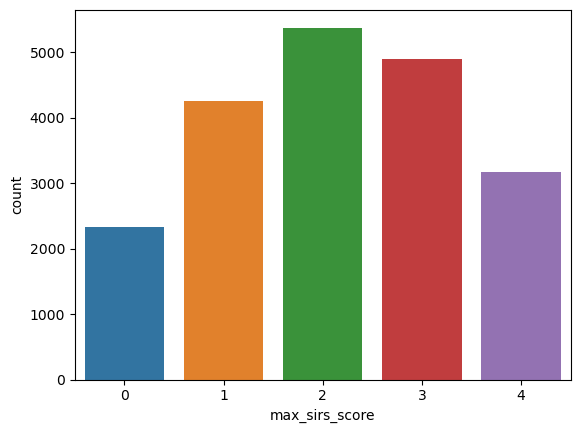

In [60]:
sns.barplot(
    data=df_sirs_max_grb.to_pandas(),
    y='count',
	x='max_sirs_score'
)

<Axes: xlabel='max_sirs_score', ylabel='max_time_diff'>

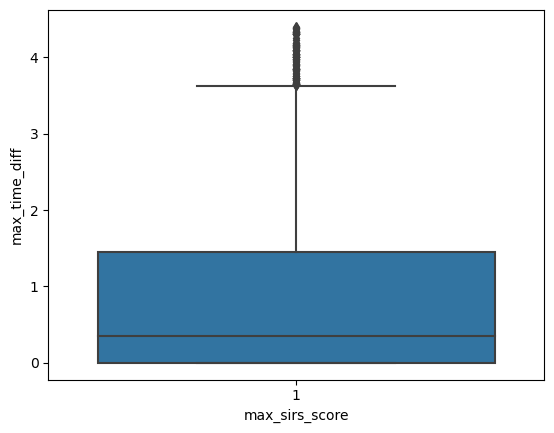

In [83]:
arr = ttres.filter(pl.col("max_sirs_score") == 1)['max_time_diff'].to_numpy()
np.percentile(arr, [0, 25, 50, 75, 95, 99, 100])
sns.boxplot(data=ttres.filter(
    (pl.col("max_sirs_score") == 1)&
	(pl.col("max_time_diff") <= pl.col("min_time_diff").quantile(0.6))&
	(pl.col("max_time_diff") >= pl.col("min_time_diff").quantile(0.3))
).to_pandas(),
x = 'max_sirs_score',
y='max_time_diff'
)

<Axes: xlabel='max_sirs_score', ylabel='max_time_diff'>

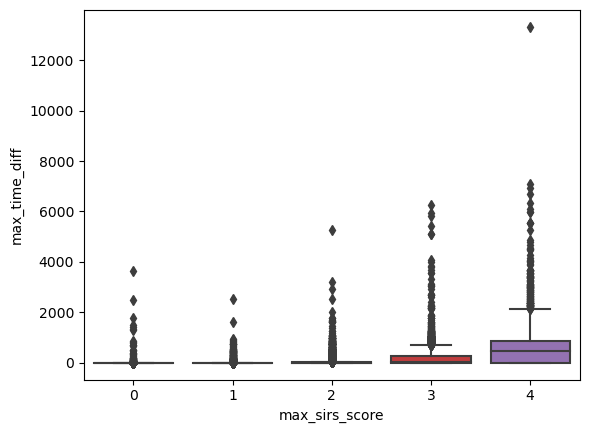

In [ ]:
ttres_sirs_1 = (
    
)

sns.boxplot(
    data=ttres.to_pandas(),
	x = 'max_sirs_score',
	y = 'max_time_diff'
)

In [ ]:
df_sirs_sub.with_columns(
    pl.col("sirs_score").shift(1).over("EncounterEpicCsn").alias("prev_sirs_score")
).filter(pl.col("sirs_score") != pl.col("prev_sirs_score"))

In [ ]:
df_enc_sirs_grb = df_sirs_sub.group_by(["EncounterEpicCsn", "sirs_score"]).agg(
    pl.col("Event_DateTime").min().alias("min_instant")
).sort(by=['EncounterEpicCsn', 'min_instant'])

In [ ]:
df_sirs.filter(
    (pl.col("EncounterEpicCsn") == 709516764)&
    (pl.col("Event_DateTime") == dt.datetime(2025, 1, 28, 5, 35))&
	(pl.col("Event_Grouper").is_in(["Pulse", "Respirations", "Temperature", "Blood Pressure"]))
)

In [ ]:
df_diff_instant = df_enc_sirs_grb.with_columns(
    pl.col("min_instant").shift(1).over("EncounterEpicCsn").alias("prev_min_instant")
).with_columns(
	# pl.col("min_instant").diff(pl.col("prev_min_instant")).dt.total_hours(fractional=True).alias("diff_instant")
	(pl.col("min_instant")-pl.col("prev_min_instant")).dt.total_hours(fractional=True).alias("diff_instant")
)

sirs_scores_lists = []
for sscore in [1, 2, 3, 4]:
	sirs_scores_lists.append(
		df_diff_instant.filter((pl.col("sirs_score") == sscore) & (pl.col("diff_instant")<100))['diff_instant'].to_numpy()
	)
		

In [ ]:
go.Figure(data=[go.Box(
	y=sirs_scores_lists[0],
)]).add_trace(
    go.Box(
		y=sirs_scores_lists[1],
	)
).add_trace(
	go.Box(
		y=sirs_scores_lists[2],
	)
).add_trace(
	go.Box(
		y=sirs_scores_lists[3],
	)
).update_layout(
	# title="Box plot of time between SIRS scores",
	xaxis_title="SIRS Score",
	# xaxis_tickvals=[1, 2, 3, 4],
	xaxis_ticktext=["1", "2", "3", "4"],
)

In [ ]:
sirs_scores_lists[0]

In [ ]:
df_sepsis1.columns

In [ ]:
# dd1 = dd1.filter(
# 	(pl.col(self.severitysepsisconfig.event_dt_col) >= pl.col(self.severitysepsisconfig.suspected_infection_config.value_name_dt_col) - pl.duration(hours=24))&
# 	(pl.col(self.severitysepsisconfig.event_dt_col) <= pl.col(self.severitysepsisconfig.suspected_infection_config.value_name_dt_col) + pl.duration(hours=24))
# )

In [4]:
def sepsis_1_from_infect_sirs(df_infect, df_sirs, min_hrs=24, max_hrs=48):
	dd1 = df_infect.join(
		df_sirs.filter(
			pl.col('sirs_score') >= 2
		),
		on="EncounterEpicCsn",
		how="left"
	)

	dd = dd1.filter(
		(pl.col("Event_DateTime") >= pl.col("infect_dt") - pl.duration(hours=min_hrs))&
		(pl.col("Event_DateTime") <= pl.col("infect_dt") + pl.duration(hours=max_hrs))
	)

	df_sepsis_1 = dd.select(
		[    "EncounterEpicCsn", "infect_dt", "criterion", "Event_DateTime","sirs_score"]+
		[c for c in dd.columns if c.endswith('_Flag') and 'Death' not in c]
	)

	df_sepsis_1 = df_sepsis_1.with_columns(
		(pl.col("infect_dt")-pl.col("Event_DateTime")).dt.total_hours(fractional=True).alias("diff_instant_hrs"),
		pl.concat_str(
			[
				pl.when(pl.col("WBC_Abnormal_Flag") == 1)
				.then(pl.lit("WBC"))
				.otherwise(pl.lit(None)),

				pl.when(pl.col("Temp_Abnormal_Flag") == 1)
				.then(pl.lit("Temp"))
				.otherwise(pl.lit(None)),

				pl.when(pl.col("Resp_Rate_High_Flag") == 1)
				.then(pl.lit("Resp"))
				.otherwise(pl.lit(None)),

				pl.when(pl.col("Pule_High_Flag") == 1)
				.then(pl.lit("Pulse"))
				.otherwise(pl.lit(None)),
			],
			separator=",",
			ignore_nulls=True,    # skips empty strings so you don't get "WBC++Resp"
		).alias("sirs_due_to")
	)
	return df_sepsis_1

In [6]:
min_hrs = 24
max_hrs = 24
df_sepsis1 = sepsis_1_from_infect_sirs(df_infect, df_sirs, min_hrs, max_hrs)


Text(0.5, 1.0, 'Box plot of time between Infection to SIRS score >= 2 with time interval -24 hours to +24 hours')

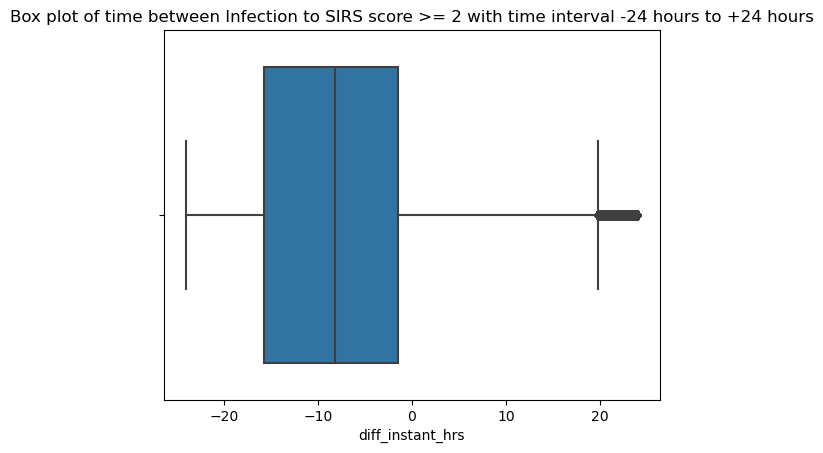

In [7]:

ax = sns.boxplot(data=df_sepsis1.to_pandas(), x='diff_instant_hrs')
ax.set_title(f"Box plot of time between Infection to SIRS score >= 2 with time interval -{min_hrs} hours to +{max_hrs} hours")

In [26]:
sirs_due_to = df_sepsis1.filter(
	(pl.col("sirs_score") >= 0)
).unique(subset=["EncounterEpicCsn", "sirs_due_to"])['sirs_due_to'].to_list()


In [35]:
df_sepsis1['EncounterEpicCsn'].n_unique(), df_sepsis1.shape

(3822, (4198348, 11))

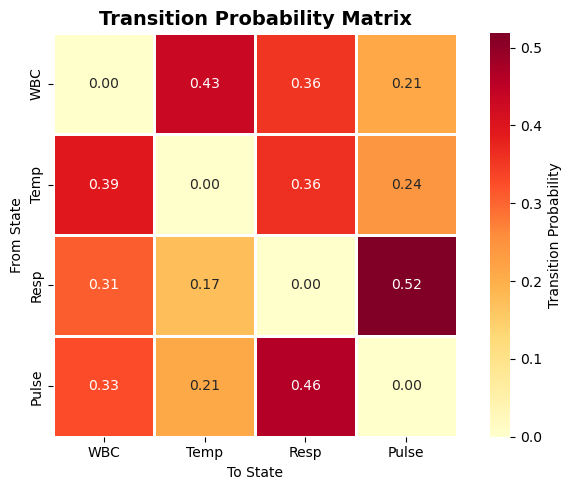

In [42]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

states = ['WBC', 'Temp', 'Resp', 'Pulse']
matrix = pd.DataFrame(0.0, index=states, columns=states)

for (src, dst), count in transitions.items():
    if count > 0:
        matrix.loc[src, dst] = count

# Normalize rows to get probabilities
matrix = matrix.div(matrix.sum(axis=1), axis=0)

plt.figure(figsize=(7, 5))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=1, linecolor='white', square=True,
            cbar_kws={'label': 'Transition Probability'})
plt.title('Transition Probability Matrix', fontsize=14, fontweight='bold')
plt.xlabel('To State')
plt.ylabel('From State')
plt.tight_layout()
plt.show()


In [30]:
single_cntr = defaultdict(int)
double_cntr = defaultdict(int)
triple_cntr = defaultdict(int)
quad_cntr = defaultdict(int)

for s in sirs_due_to:
	d = s.split(',')
	if len(d) == 1:
		single_cntr[d[0]] += 1
	elif len(d) == 2:
		single_cntr[d[0]] += 1
		single_cntr[d[1]] += 1
		double_cntr[(d[0], d[1])] += 1
	elif len(d) == 3:
		single_cntr[d[0]] += 1
		single_cntr[d[1]] += 1
		single_cntr[d[2]] += 1
		double_cntr[(d[0], d[1])] += 1
		double_cntr[(d[1], d[2])] += 1
		triple_cntr[(d[0], d[1], d[2])] += 1
	elif len(d) == 4:
		single_cntr[d[0]] += 1
		single_cntr[d[1]] += 1
		single_cntr[d[2]] += 1
		single_cntr[d[3]] += 1
		double_cntr[(d[0], d[1])] += 1
		double_cntr[(d[1], d[2])] += 1
		double_cntr[(d[2], d[3])] += 1
		triple_cntr[(d[0], d[1], d[2])] += 1
		triple_cntr[(d[1], d[2], d[3])] += 1
		quad_cntr[(d[0], d[1], d[2], d[3])] += 1


In [ ]:
from collections import Counter, defaultdict
import plotly.graph_objects as go


def plot_transition_sankey_from_paths(
    events,
    title="State Transition Sankey Diagram",
    min_count=1,
    normalize=False,
    width=900,
    height=600,
):
    """
    Plot a Sankey diagram from counted state sequences.

    Parameters
    ----------
    events : dict or defaultdict
        Keys are state sequences, e.g. ("S1", "S2", "S3").
        Values are counts, e.g. 10.
    title : str
        Plot title.
    min_count : int
        Minimum transition count to include.
    normalize : bool
        If True, edge values are row-normalized transition probabilities.
        If False, edge values are raw transition counts.
    width : int
        Figure width.
    height : int
        Figure height.

    Returns
    -------
    fig : plotly.graph_objects.Figure
    """

    transition_counts = Counter()
    all_states = set()

    # Convert counted paths into counted pairwise transitions
    for path, path_count in events.items():
        path = tuple(path)

        if len(path) < 2:
            continue

        all_states.update(path)

        for src, dst in zip(path[:-1], path[1:]):
            transition_counts[(src, dst)] += path_count

    # Filter rare transitions
    transition_counts = Counter({
        transition: count
        for transition, count in transition_counts.items()
        if count >= min_count
    })

    if not transition_counts:
        raise ValueError("No transitions found after applying min_count.")

    states = sorted(all_states)
    state_to_idx = {state: i for i, state in enumerate(states)}

    sources = []
    targets = []
    values = []
    hover_labels = []

    if normalize:
        outgoing_counts = defaultdict(float)

        for (src, dst), count in transition_counts.items():
            outgoing_counts[src] += count

        for (src, dst), count in transition_counts.items():
            prob = count / outgoing_counts[src]

            sources.append(state_to_idx[src])
            targets.append(state_to_idx[dst])
            values.append(prob)
            hover_labels.append(
                f"{src} → {dst}<br>"
                f"Count: {count}<br>"
                f"P({dst} | {src}) = {prob:.3f}"
            )

    else:
        for (src, dst), count in transition_counts.items():
            sources.append(state_to_idx[src])
            targets.append(state_to_idx[dst])
            values.append(count)
            hover_labels.append(
                f"{src} → {dst}<br>"
                f"Count: {count}"
            )

    fig = go.Figure(
        data=[
            go.Sankey(
                node=dict(
                    pad=20,
                    thickness=20,
                    line=dict(width=0.5),
                    label=[str(s) for s in states],
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    customdata=hover_labels,
                    hovertemplate="%{customdata}<extra></extra>",
                ),
            )
        ]
    )

    fig.update_layout(
        title=title,
        width=width,
        height=height,
        font=dict(size=14),
    )

    fig.show()

    return figfrom collections import Counter, defaultdict
import plotly.graph_objects as go


def plot_transition_sankey_from_paths(
    events,
    title="State Transition Sankey Diagram",
    min_count=1,
    normalize=False,
    width=900,
    height=600,
):
    """
    Plot a Sankey diagram from counted state sequences.

    Parameters
    ----------
    events : dict or defaultdict
        Keys are state sequences, e.g. ("S1", "S2", "S3").
        Values are counts, e.g. 10.
    title : str
        Plot title.
    min_count : int
        Minimum transition count to include.
    normalize : bool
        If True, edge values are row-normalized transition probabilities.
        If False, edge values are raw transition counts.
    width : int
        Figure width.
    height : int
        Figure height.

    Returns
    -------
    fig : plotly.graph_objects.Figure
    """

    transition_counts = Counter()
    all_states = set()

    # Convert counted paths into counted pairwise transitions
    for path, path_count in events.items():
        path = tuple(path)

        if len(path) < 2:
            continue

        all_states.update(path)

        for src, dst in zip(path[:-1], path[1:]):
            transition_counts[(src, dst)] += path_count

    # Filter rare transitions
    transition_counts = Counter({
        transition: count
        for transition, count in transition_counts.items()
        if count >= min_count
    })

    if not transition_counts:
        raise ValueError("No transitions found after applying min_count.")

    states = sorted(all_states)
    state_to_idx = {state: i for i, state in enumerate(states)}

    sources = []
    targets = []
    values = []
    hover_labels = []

    if normalize:
        outgoing_counts = defaultdict(float)

        for (src, dst), count in transition_counts.items():
            outgoing_counts[src] += count

        for (src, dst), count in transition_counts.items():
            prob = count / outgoing_counts[src]

            sources.append(state_to_idx[src])
            targets.append(state_to_idx[dst])
            values.append(prob)
            hover_labels.append(
                f"{src} → {dst}<br>"
                f"Count: {count}<br>"
                f"P({dst} | {src}) = {prob:.3f}"
            )

    else:
        for (src, dst), count in transition_counts.items():
            sources.append(state_to_idx[src])
            targets.append(state_to_idx[dst])
            values.append(count)
            hover_labels.append(
                f"{src} → {dst}<br>"
                f"Count: {count}"
            )

    fig = go.Figure(
        data=[
            go.Sankey(
                node=dict(
                    pad=20,
                    thickness=20,
                    line=dict(width=0.5),
                    label=[str(s) for s in states],
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    customdata=hover_labels,
                    hovertemplate="%{customdata}<extra></extra>",
                ),
            )
        ]
    )

    fig.update_layout(
        title=title,
        width=width,
        height=height,
        font=dict(size=14),
    )

    fig.show()

    return fig

In [73]:

fig = plot_transition_sankey_from_paths(
    triple_cntr,
    title="State Transition Sankey Diagram",
    min_count=1,
    normalize=False,
    width=900,
    height=600,
)

fig

In [ ]:
single_cntr


defaultdict(int,
            {'WBC': 4945, 'Resp': 5783, 'Pulse': 7497, 'Temp': 3794, 0: 0})

<Axes: xlabel='flag', ylabel='count'>

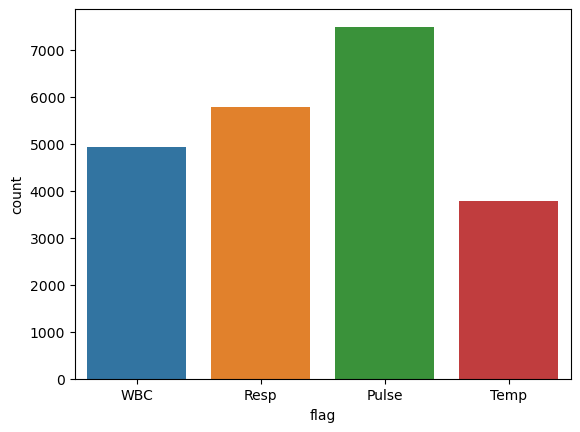

In [68]:
sns.barplot(pd.DataFrame(single_cntr.items(), columns=['flag', 'count']).iloc[:-1], x='flag', y='count')

In [31]:
single_cntr

defaultdict(int, {'WBC': 4945, 'Resp': 5783, 'Pulse': 7497, 'Temp': 3794})

In [32]:
double_cntr

defaultdict(int,
            {('WBC', 'Resp'): 1758,
             ('Resp', 'Pulse'): 5287,
             ('Temp', 'Pulse'): 1166,
             ('WBC', 'Temp'): 2143,
             ('Temp', 'Resp'): 2548,
             ('WBC', 'Pulse'): 1044})

In [33]:
triple_cntr

defaultdict(int,
            {('WBC', 'Resp', 'Pulse'): 1517,
             ('WBC', 'Temp', 'Resp'): 1562,
             ('Temp', 'Resp', 'Pulse'): 2293,
             ('WBC', 'Temp', 'Pulse'): 501})

In [34]:
quad_cntr

defaultdict(int, {('WBC', 'Temp', 'Resp', 'Pulse'): 1447})

In [ ]:
dfs = df_sirs.select(
	["EncounterEpicCsn",
	"Event_DateTime",
	]+
	[
		c for c in df_sirs.columns if c.endswith("_Flag") and 'Death' not in c
	]+[
		"sirs_score"
	]
).unique(subset=["EncounterEpicCsn", "Event_DateTime", "sirs_score"]).sort(by=["EncounterEpicCsn", "Event_DateTime"])

In [ ]:
dfs.shape

In [ ]:
df_temp = dfs.group_by(["EncounterEpicCsn", "Event_DateTime"]).agg(
	pl.col("sirs_score").max()
).join(
	dfs,
	on=['EncounterEpicCsn', 'Event_DateTime', 'sirs_score']
)


for row in df_temp.iter_rows(named=True):
